In [3]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


Cell 2 — Install packages

In [3]:
!pip install -q ultralytics opencv-python tqdm pyyaml matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.1 MB/s eta 0:00:00:00:01


Cell 3 — Imports

In [4]:
from pathlib import Path
import json
import re
import shutil
import zipfile
from collections import defaultdict

import cv2
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Cell 4 — Find your Kaggle input path

In [7]:
!ls /kaggle/input/datasets/saifdewan/yolo-drone-eval

kaggle_local_drone_eval


In [5]:
INPUT_DIR = Path("/kaggle/input/datasets/saifdewan/yolo-drone-eval/kaggle_local_drone_eval")  # change if your dataset name is different

ANNOTATION_DIR = INPUT_DIR / "extracted_annotation_jobs"
VIDEO_DIR = INPUT_DIR / "local_videos"
MODEL_PATH = INPUT_DIR / "model" / "best.pt"

WORK_DIR = Path("/kaggle/working")
LOCAL_YOLO_DIR = WORK_DIR / "local_drone_yolo_eval"

print("Input exists:", INPUT_DIR.exists())
print("Annotation folder exists:", ANNOTATION_DIR.exists())
print("Video folder exists:", VIDEO_DIR.exists())
print("Model exists:", MODEL_PATH.exists())

Input exists: True
Annotation folder exists: True
Video folder exists: True
Model exists: True


Cell 5 — List annotation jobs and videos

In [12]:
job_zips = sorted(EXTRACTED_ANNOT_DIR.glob("*.zip"))

video_files = []
for ext in ["*.mp4", "*.mov", "*.avi", "*.mkv"]:
    video_files.extend(LOCAL_VIDEO_DIR.glob(ext))

video_files = sorted(video_files)

print("Annotation jobs:")
for i, z in enumerate(job_zips):
    print(f"{i}: {z.name}")

print("\nVideos:")
for i, v in enumerate(video_files):
    print(f"{i}: {v.name}")

NameError: name 'EXTRACTED_ANNOT_DIR' is not defined

Cell 6 — Inspect one annotation job

In [6]:
annotation_jsons = sorted([
    p for p in INPUT_DIR.rglob("instances_default.json")
])

video_files = sorted([
    p for p in INPUT_DIR.rglob("*")
    if p.suffix.lower() in [".mp4", ".mov", ".avi", ".mkv"]
])

print("Annotation JSONs found:", len(annotation_jsons))
for i, p in enumerate(annotation_jsons):
    print(f"ANN {i}: {p}")

print("\nVideos found:", len(video_files))
for i, p in enumerate(video_files):
    print(f"VID {i}: {p.name} | {p}")

Annotation JSONs found: 11
ANN 0: /kaggle/input/datasets/saifdewan/yolo-drone-eval/kaggle_local_drone_eval/extracted_annotation_jobs/job_10_annotations_2026_04_07_17_14_54_coco 1.0/annotations/instances_default.json
ANN 1: /kaggle/input/datasets/saifdewan/yolo-drone-eval/kaggle_local_drone_eval/extracted_annotation_jobs/job_11_annotations_2026_04_07_17_28_59_coco 1.0/annotations/instances_default.json
ANN 2: /kaggle/input/datasets/saifdewan/yolo-drone-eval/kaggle_local_drone_eval/extracted_annotation_jobs/job_12_annotations_2026_04_09_16_27_35_coco 1.0/annotations/instances_default.json
ANN 3: /kaggle/input/datasets/saifdewan/yolo-drone-eval/kaggle_local_drone_eval/extracted_annotation_jobs/job_2_annotations_2026_03_06_09_42_36_coco 1.0/annotations/instances_default.json
ANN 4: /kaggle/input/datasets/saifdewan/yolo-drone-eval/kaggle_local_drone_eval/extracted_annotation_jobs/job_3_annotations_2026_04_08_17_20_23_coco 1.0/annotations/instances_default.json
ANN 5: /kaggle/input/datasets/

In [7]:
def inspect_annotation_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    print("Annotation file:", json_path)
    print("Images:", len(coco.get("images", [])))
    print("Annotations:", len(coco.get("annotations", [])))
    print("Categories:", coco.get("categories", []))

    print("\nSample image entries:")
    for img in coco["images"][:5]:
        print(img)

inspect_annotation_json(annotation_jsons[9]) #1,6

Annotation file: /kaggle/input/datasets/saifdewan/yolo-drone-eval/kaggle_local_drone_eval/extracted_annotation_jobs/job_8_annotations_2026_04_08_19_32_43_coco 1.0/annotations/instances_default.json
Images: 1093
Annotations: 3208
Categories: [{'id': 1, 'name': 'Drone', 'supercategory': ''}]

Sample image entries:
{'id': 1, 'width': 2400, 'height': 1080, 'file_name': 'frame_000000.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
{'id': 2, 'width': 2400, 'height': 1080, 'file_name': 'frame_000001.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
{'id': 3, 'width': 2400, 'height': 1080, 'file_name': 'frame_000002.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
{'id': 4, 'width': 2400, 'height': 1080, 'file_name': 'frame_000003.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
{'id': 5, 'width': 2400, 'height': 1080, 'file_name': 'frame_000004.png', 'license': 0, 'flickr_url': '', 'coco_url': 

Cell 7 — Create annotation-to-video mapping

In [8]:
for i, ann in enumerate(annotation_jsons):
    print(f"ANN {i}: {ann.parent.parent.name}")

print("\n")

for i, vid in enumerate(video_files):
    print(f"VID {i}: {vid.name}")

ANN 0: job_10_annotations_2026_04_07_17_14_54_coco 1.0
ANN 1: job_11_annotations_2026_04_07_17_28_59_coco 1.0
ANN 2: job_12_annotations_2026_04_09_16_27_35_coco 1.0
ANN 3: job_2_annotations_2026_03_06_09_42_36_coco 1.0
ANN 4: job_3_annotations_2026_04_08_17_20_23_coco 1.0
ANN 5: job_4_annotations_2026_03_06_17_04_04_coco 1.0
ANN 6: job_5_annotations_2026_04_08_18_23_32_coco 1.0
ANN 7: job_6_annotations_2026_04_09_15_53_31_coco 1.0
ANN 8: job_7_annotations_2026_03_06_15_01_07_coco 1.0
ANN 9: job_8_annotations_2026_04_08_19_32_43_coco 1.0
ANN 10: job_9_annotations_2026_04_07_17_27_38_coco 1.0


VID 0: Vid1.mp4
VID 1: Vid10.mp4
VID 2: Vid11.mp4
VID 3: Vid2.mp4
VID 4: Vid3.mp4
VID 5: Vid4.mp4
VID 6: Vid5.mp4
VID 7: Vid6.mp4
VID 8: Vid7.mp4
VID 9: Vid8.mp4
VID 10: Vid9.mp4


In [79]:
JSON_TO_VIDEO = {
    str(annotation_jsons[1]): str(video_files[8]),
} #0to9

In [80]:
for ann_path, video_path in JSON_TO_VIDEO.items():
    print(Path(ann_path).parent.parent.name, " --> ", Path(video_path).name)

job_11_annotations_2026_04_07_17_28_59_coco 1.0  -->  Vid7.mp4


Cell 8 — Helper functions

In [81]:
def reset_output_dir(output_dir: Path):
    if output_dir.exists():
        shutil.rmtree(output_dir)

    (output_dir / "images" / "test").mkdir(parents=True, exist_ok=True)
    (output_dir / "labels" / "test").mkdir(parents=True, exist_ok=True)


def get_frame_index(file_name: str):
    match = re.search(r"frame_(\d+)", file_name)

    if match is None:
        return None

    return int(match.group(1))


def coco_bbox_to_yolo(bbox, img_w, img_h):
    """
    COCO bbox format:
    [x_min, y_min, width, height]

    YOLO bbox format:
    x_center, y_center, width, height
    all normalized between 0 and 1
    """
    x, y, w, h = bbox

    x_center = x + w / 2
    y_center = y + h / 2

    x_center /= img_w
    y_center /= img_h
    w /= img_w
    h /= img_h

    x_center = min(max(x_center, 0), 1)
    y_center = min(max(y_center, 0), 1)
    w = min(max(w, 0), 1)
    h = min(max(h, 0), 1)

    return x_center, y_center, w, h


def convert_one_json_to_yolo(
    annotation_json_path: Path,
    video_path: Path,
    output_dir: Path,
    frame_step: int = 1,
    frame_offset: int = 0,
):
    with open(annotation_json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    images = coco["images"]
    annotations = coco["annotations"]

    anns_by_image_id = defaultdict(list)

    for ann in annotations:
        anns_by_image_id[ann["image_id"]].append(ann)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    job_name = annotation_json_path.parent.parent.name
    job_stem = job_name.replace(" ", "_").replace(".", "_")

    saved_count = 0
    skipped_count = 0

    for img_info in tqdm(images, desc=f"Converting {job_name}"):
        file_name = img_info["file_name"]
        frame_idx = get_frame_index(file_name)

        if frame_idx is None:
            skipped_count += 1
            continue

        if frame_idx % frame_step != 0:
            continue

        actual_frame_idx = frame_idx + frame_offset

        if actual_frame_idx < 0:
            skipped_count += 1
            continue

        cap.set(cv2.CAP_PROP_POS_FRAMES, actual_frame_idx)
        success, frame = cap.read()

        if not success:
            skipped_count += 1
            continue

        img_h, img_w = frame.shape[:2]

        out_stem = f"{job_stem}_frame_{frame_idx:06d}"

        image_out_path = output_dir / "images" / "test" / f"{out_stem}.jpg"
        label_out_path = output_dir / "labels" / "test" / f"{out_stem}.txt"

        cv2.imwrite(str(image_out_path), frame)

        label_lines = []

        for ann in anns_by_image_id.get(img_info["id"], []):
            bbox = ann["bbox"]

            x_center, y_center, w, h = coco_bbox_to_yolo(
                bbox=bbox,
                img_w=img_w,
                img_h=img_h
            )

            if w <= 0 or h <= 0:
                continue

            class_id = 0  # drone
            label_lines.append(
                f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"
            )

        with open(label_out_path, "w", encoding="utf-8") as f:
            f.write("\n".join(label_lines))

        saved_count += 1

    cap.release()

    return saved_count, skipped_count

Cell 9 — Debug conversion using fewer frames

In [82]:
reset_output_dir(LOCAL_YOLO_DIR)

FRAME_STEP = 5
FRAME_OFFSET = 0

total_saved = 0
total_skipped = 0

for ann_path_str, video_path_str in JSON_TO_VIDEO.items():
    annotation_json_path = Path(ann_path_str)
    video_path = Path(video_path_str)

    saved, skipped = convert_one_json_to_yolo(
        annotation_json_path=annotation_json_path,
        video_path=video_path,
        output_dir=LOCAL_YOLO_DIR,
        frame_step=FRAME_STEP,
        frame_offset=FRAME_OFFSET,
    )

    total_saved += saved
    total_skipped += skipped

    print(
        f"{annotation_json_path.parent.parent.name} -> {video_path.name}: "
        f"saved={saved}, skipped={skipped}"
    )

print("\nTotal saved frames:", total_saved)
print("Total skipped frames:", total_skipped)
print("Output folder:", LOCAL_YOLO_DIR)

Converting job_11_annotations_2026_04_07_17_28_59_coco 1.0:   0%|          | 0/5642 [00:00<?, ?it/s]

job_11_annotations_2026_04_07_17_28_59_coco 1.0 -> Vid7.mp4: saved=425, skipped=704

Total saved frames: 425
Total skipped frames: 704
Output folder: /kaggle/working/local_drone_yolo_eval


Cell 10 — Create YOLO dataset YAML

In [84]:
local_data_yaml = {
    "path": str(LOCAL_YOLO_DIR),
    "train": "images/test",
    "val": "images/test",
    "test": "images/test",
    "names": {
        0: "drone"
    }
}

local_yaml_path = LOCAL_YOLO_DIR / "local_data.yaml"

with open(local_yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(local_data_yaml, f, sort_keys=False)

print(local_yaml_path)

with open(local_yaml_path, "r", encoding="utf-8") as f:
    print(f.read())

/kaggle/working/local_drone_yolo_eval/local_data.yaml
path: /kaggle/working/local_drone_yolo_eval
train: images/test
val: images/test
test: images/test
names:
  0: drone



Cell 11 — Visual check of ground-truth boxes

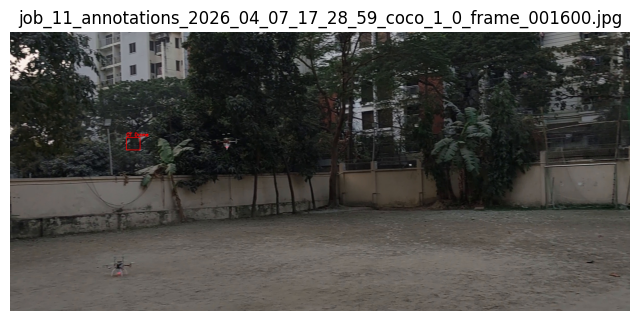

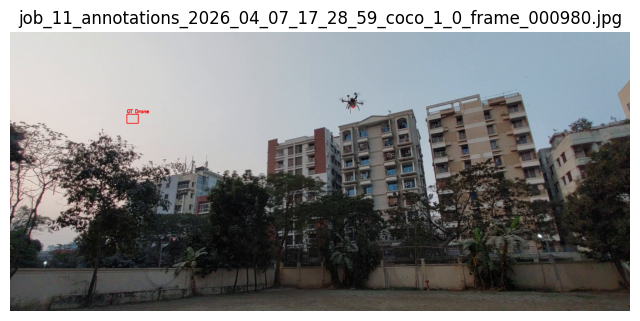

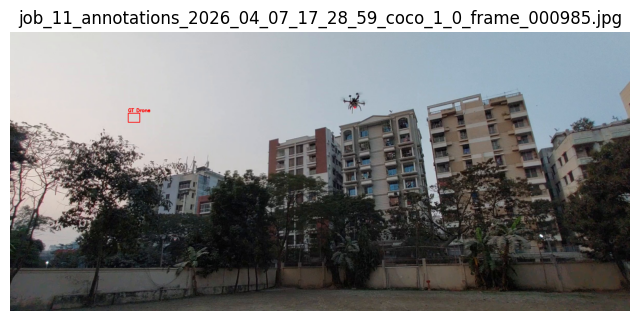

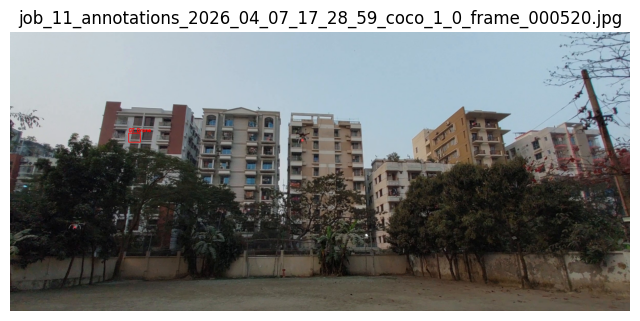

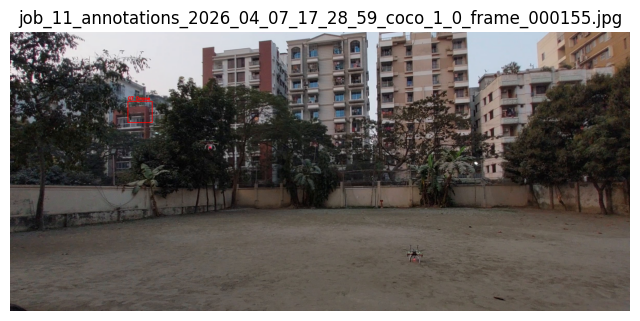

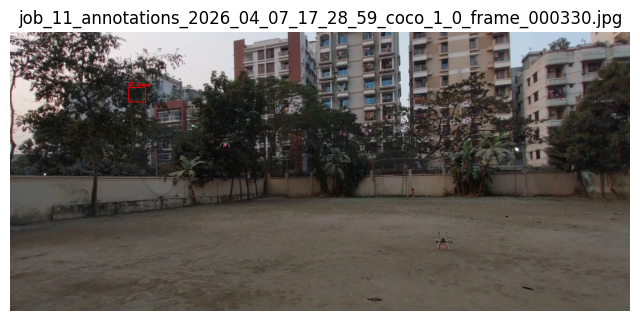

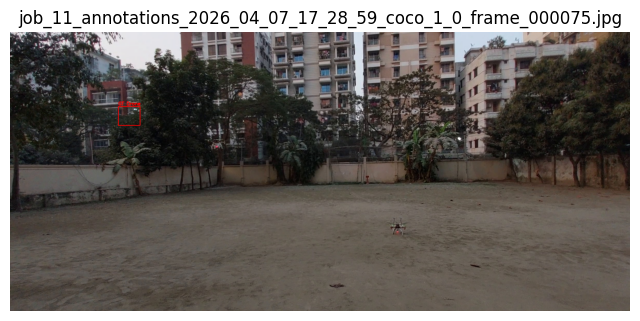

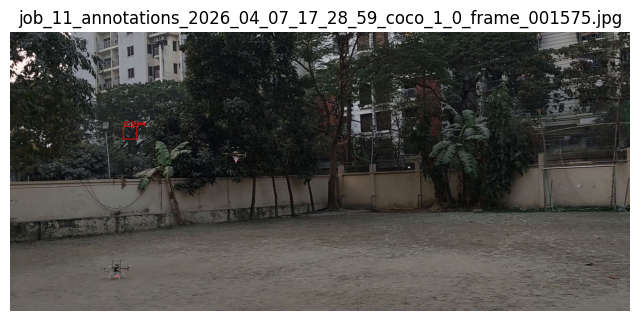

In [85]:
import random

def visualize_yolo_ground_truth(dataset_dir: Path, n=8):
    image_dir = dataset_dir / "images" / "test"
    label_dir = dataset_dir / "labels" / "test"

    image_files = list(image_dir.glob("*.jpg"))

    if len(image_files) == 0:
        print("No images found.")
        return

    sample_files = random.sample(image_files, min(n, len(image_files)))

    for img_path in sample_files:
        label_path = label_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))

        if img is None:
            print("Could not read:", img_path)
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w = img.shape[:2]

        if label_path.exists():
            lines = label_path.read_text().strip().splitlines()

            for line in lines:
                if not line.strip():
                    continue

                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(
                    img,
                    "GT Drone",
                    (x1, max(y1 - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 0, 0),
                    2
                )

        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
        plt.show()

visualize_yolo_ground_truth(LOCAL_YOLO_DIR, n=8)